# strength index via Elo

In [21]:
import os
import pandas as pd
import numpy as np

In [22]:
processed_path = os.path.join('c:\\Users\\Trainee.LAPTOP-7OL45FO7\\Desktop\\portfolio_projekt\\template_dsc', 'data', 'processed')

if os.path.exists(processed_path):
    print('True')


# get data
df_final_rankings = pd.read_csv(os.path.join(processed_path, 'Bundesliga_Rankings.csv'))
df_matches = pd.read_csv(os.path.join(processed_path, 'Bundesliga_Matches.csv'))

display(df_final_rankings.head())
display(df_matches.head())

True


,League,SEASON,Team,Team_Short,Matches,Points,Won,Lost,Draw,Goals,Opponent_Goals,GoalDiff,Rank,Ratings_initial
0,1. Bundesliga,04_05,FC Bayern München,Bayern,34,77,24,5,5,75,33,42,1,100.000000
1,1. Bundesliga,04_05,FC Schalke 04,Schalke,34,63,20,11,3,56,46,10,2,94.176471
2,1. Bundesliga,04_05,Werder Bremen,Bremen,34,59,18,11,5,68,37,31,3,88.352941
3,1. Bundesliga,04_05,Hertha BSC,Hertha,34,58,15,6,13,59,31,28,4,82.529412
4,1. Bundesliga,04_05,VfB Stuttgart,Stuttgart,34,58,17,10,7,54,40,14,5,76.705882


,MATCH_DATE,SEASON,LOCATION,MATCHDAY_NR,HOME_TEAM_NAME,AWAY_TEAM_NAME,GOALS_HOME,GOALS_AWAY,DRAW,WIN_HOME,WIN_AWAY
0,2005-08-05 20:30:00,05_06,München,1,FC Bayern München,Borussia Mönchengladbach,3,0,0.0,1.0,0.0
1,2005-08-06 15:30:00,05_06,Köln,1,1. FC Köln,1. FSV Mainz 05,1,0,0.0,1.0,0.0
2,2005-08-06 15:30:00,05_06,Duisburg,1,MSV Duisburg,VfB Stuttgart,1,1,1.0,0.0,0.0
3,2005-08-06 15:30:00,05_06,Hamburg,1,Hamburger SV,1. FC Nürnberg,3,0,0.0,1.0,0.0
4,2005-08-06 15:30:00,05_06,Wolfsburg,1,VfL Wolfsburg,Borussia Dortmund,2,2,1.0,0.0,0.0


In [23]:
# focus on 5 comparable seasons: 09_10 to 14_15

df_rankings_5 = df_final_rankings.copy()
df_matches_5 = df_matches.copy()
dfs = [df_rankings_5, df_matches_5]

for df in dfs: 
    df = df[(df['SEASON'] == '09_10') | (df['SEASON'] == '10_11') | (df['SEASON'] == '11_12') | (df['SEASON'] == '12_13') | (df['SEASON'] == '13_14') | (df['SEASON'] == '14_15')]
    display(df.head())
    display(df.tail())


,League,SEASON,Team,Team_Short,Matches,Points,Won,Lost,Draw,Goals,Opponent_Goals,GoalDiff,Rank,Ratings_initial
90,1. Bundesliga,09_10,FC Bayern München,Bayern,34,70,20,4,10,72,31,41,1,100.000000
91,1. Bundesliga,09_10,FC Schalke 04,Schalke,34,65,19,7,8,53,31,22,2,94.176471
92,1. Bundesliga,09_10,Werder Bremen,Bremen,34,61,17,7,10,71,40,31,3,88.352941
93,1. Bundesliga,09_10,Bayer Leverkusen,Leverkusen,34,59,15,5,14,65,38,27,4,82.529412
94,1. Bundesliga,09_10,Borussia Dortmund,Dortmund,34,57,16,9,9,54,42,12,5,76.705882


,League,SEASON,Team,Team_Short,Matches,Points,Won,Lost,Draw,Goals,Opponent_Goals,GoalDiff,Rank,Ratings_initial
193,1. Bundesliga,14_15,VfB Stuttgart,Stuttgart,34,36,9,16,9,42,60,-18,14,24.294118
194,1. Bundesliga,14_15,Hertha BSC,Hertha,34,35,9,17,8,36,52,-16,15,18.470588
195,1. Bundesliga,14_15,Hamburger SV,HSV,34,35,9,17,8,25,50,-25,16,12.647059
196,1. Bundesliga,14_15,SC Freiburg,Freiburg,34,34,7,14,13,36,47,-11,17,6.823529
197,1. Bundesliga,14_15,SC Paderborn 07,Paderborn,34,31,7,17,10,31,65,-34,18,1.000000


,MATCH_DATE,SEASON,LOCATION,MATCHDAY_NR,HOME_TEAM_NAME,AWAY_TEAM_NAME,GOALS_HOME,GOALS_AWAY,DRAW,WIN_HOME,WIN_AWAY
1224,2009-08-07 20:30:00,09_10,Wolfsburg,1,VfL Wolfsburg,VfB Stuttgart,2,0,0.0,1.0,0.0
1225,2009-08-08 15:30:00,09_10,Dortmund,1,Borussia Dortmund,1. FC Köln,1,0,0.0,1.0,0.0
1226,2009-08-08 15:30:00,09_10,Nürnberg,1,1. FC Nürnberg,FC Schalke 04,1,2,0.0,0.0,1.0
1227,2009-08-08 15:30:00,09_10,Bremen,1,Werder Bremen,Eintracht Frankfurt,2,3,0.0,0.0,1.0
1228,2009-08-08 15:30:00,09_10,Berlin,1,Hertha BSC,Hannover 96,1,0,0.0,1.0,0.0


,MATCH_DATE,SEASON,LOCATION,MATCHDAY_NR,HOME_TEAM_NAME,AWAY_TEAM_NAME,GOALS_HOME,GOALS_AWAY,DRAW,WIN_HOME,WIN_AWAY
3055,2015-05-23 15:30:00,14_15,Hannover,34,Hannover 96,SC Freiburg,2,1,0.0,1.0,0.0
3056,2015-05-23 15:30:00,14_15,Frankfurt,34,Eintracht Frankfurt,Bayer Leverkusen,2,1,0.0,1.0,0.0
3057,2015-05-23 15:30:00,14_15,Hamburg,34,Hamburger SV,FC Schalke 04,2,0,0.0,1.0,0.0
3058,2015-05-23 15:30:00,14_15,Köln,34,1. FC Köln,VfL Wolfsburg,2,2,1.0,0.0,0.0
3059,2015-05-23 15:30:00,14_15,Paderborn,34,SC Paderborn 07,VfB Stuttgart,1,2,0.0,0.0,1.0


In [ ]:
# Elo ---- pseudo code

# expected score 

expect_a = 1 /(1 + 10**(-(rating_a - rating_b)/c)) # c is hyperparameter: 
                                                    # how important are rating differences
expect_b = 1- expect_a

c = 20 # for now

# victory, loss, draw 

win_draw_loss_a = 1 # if victory
win_draw_loss_a = 0.5 # if draw
win_draw_loss_a = 0 # if loss

k= update_strength


rating_a_update = rating_a + k*(win_draw_loss_a - expect_a) # wenn A Favorit (expect_a > 0.5, aber w_d_l = 0.5 dann ist Unentschieden schlecht für das Rating von A)
rating_b_update = rating_b + k*(win_draw_loss_b - expect_b)

# add goal margin
m = margin_factor # important: not applicable if draw, as otherwise m=0, see below

if win_draw_loss == 0.5:
    m=1 # equations below become equations above
    rating_a_update = rating_a + k*m*(win_draw_loss_a - expect_a) # wenn A Favorit (expect_a > 0.5, aber w_d_l = 0.5 dann ist Unentschieden schlecht für das Rating von A)
    rating_b_update = rating_b + k*m*(win_draw_loss_b - expect_b)
else:
    m = 1 + alpha*(goal_difference) # alpha = 0.25 to start with

return rating_a_update, rating_b_update

NameError: name 'rating_a' is not defined

In [25]:
# clean function within class for Elo Update

import numpy as np



class TeamStrength:
    '''
    Class for rating updates on team strength within a league via different metrics, such as Elo, Poisson and Dixon Cole
    between two teams, team A (home) and team B (away).
    '''


    def __init__(self, rating_a, rating_b, goals_a, goals_b):
        # ratings before the match
        self.rating_a = rating_a
        self.rating_b = rating_b

        # scored goals
        self.goals_a = goals_a
        self.goals_b = goals_b

    @property
    def goal_difference(self):
        '''
        Absolute goal difference of the match between team A and team B
        '''
        return np.abs(self.goals_a - self.goals_b)
    
    @property
    def score_a(self):
        if self.goals_a > self.goals_b:
            return 1.0
        elif self.goals_a < self.goals_b:
            return 0.0
        return 0.5
    
    @property
    def score_b(self):
        return 1- self.score_a


    def elo_update(self, k=10, c=20, alpha=0.25):
        '''
        Update Elo ratings after each match
        '''

        # expected score 
        expect_a = 1 /(1 + 10 ** (-(self.rating_a - self.rating_b)/c))  
                                                            
        expect_b = 1- expect_a

        # add goals
        goal_margin_factor =  1 + alpha * self.goal_difference

        # rating changes
        delta_a = k * goal_margin_factor * (self.score_a - expect_a)
        delta_b = k * goal_margin_factor * (self.score_b - expect_b)

        # updated ratings
        new_rating_a = self.rating_a + delta_a
        new_rating_b = self.rating_b + delta_b

        return {
        "expect_a": expect_a,
        "expect_b": expect_b,
        "score_a": self.score_a,
        "score_b": self.score_b,
        "goal_margin_factor": goal_margin_factor,
        "delta_a": delta_a,
        "delta_b": delta_b,
        "new_rating_a": new_rating_a,
        "new_rating_b": new_rating_b,
        }

In [26]:
## sanity check elo. clear win, draw and clear loss. First vs Third

match_win_home = TeamStrength(rating_a=100, rating_b=88.353, goals_a=3, goals_b=0)
match_draw = TeamStrength(rating_a=100, rating_b=88.353, goals_a=2, goals_b=2)
match_loss_home = TeamStrength(rating_a=100, rating_b=88.353, goals_a=0, goals_b=3)

result_win_home = match_win_home.elo_update(k=10, c=20, alpha=0.25)
result_draw = match_draw.elo_update(k=10, c=20, alpha=0.25)
result_loss_home = match_loss_home.elo_update(k=10, c=20, alpha=0.25)

print(result_win_home)
print(result_draw)
print(result_loss_home)

# take home message: works. 
# maybe investigate asymetric loss, i.e. the score the winner's rating wins is not identical to the score the loser's rating loses

{'expect_a': 0.7926396212719551, 'expect_b': 0.20736037872804491, 'score_a': 1.0, 'score_b': 0.0, 'goal_margin_factor': np.float64(1.75), 'delta_a': np.float64(3.628806627740786), 'delta_b': np.float64(-3.628806627740786), 'new_rating_a': np.float64(103.62880662774079), 'new_rating_b': np.float64(84.72419337225921)}
{'expect_a': 0.7926396212719551, 'expect_b': 0.20736037872804491, 'score_a': 0.5, 'score_b': 0.5, 'goal_margin_factor': np.float64(1.0), 'delta_a': np.float64(-2.926396212719551), 'delta_b': np.float64(2.926396212719551), 'new_rating_a': np.float64(97.07360378728045), 'new_rating_b': np.float64(91.27939621271955)}
{'expect_a': 0.7926396212719551, 'expect_b': 0.20736037872804491, 'score_a': 0.0, 'score_b': 1.0, 'goal_margin_factor': np.float64(1.75), 'delta_a': np.float64(-13.871193372259214), 'delta_b': np.float64(13.871193372259214), 'new_rating_a': np.float64(86.12880662774079), 'new_rating_b': np.float64(102.22419337225921)}


In [ ]:
# Elo for a season or more than one season

class TeamStrengthSeason:
    '''
    Estimating the strength of a team during a whole season from match data.

    Current implementation: 
        - Elo (strength indices for teams)
    
    Planned implementations:
        - Poisson / Dixon-Coles (defensive and offensive strength as additional features)

    '''

    def __init__(self, df_matches, df_rankings, seasons):
        '''
        Extract seasons to investigate from match and rankings data.
        '''

        self.df_matches = df_matches.copy()
        self.df_rankings = df_rankings.copy()
        self.seasons  = seasons

        # keep only requested seasons
        self.df_matches = self.df_matches[self.df_matches['SEASON'].isin(seasons)].copy()
        self.df_rankings = self.df_rankings[self.df_rankings['SEASON'].isin(seasons)].copy()

    @staticmethod
    def _elo_expected_score(rating_home, rating_away, c=20):
        '''
        Expected Elo score for home team
        '''

        return 1 / (1 + 10 ** (-(rating_home - rating_away) / c))
    
    @staticmethod
    def _actual_score(goals_home, goals_away):
        """
        Actual Elo score for the home team.
        """
        if goals_home > goals_away:
            return 1.0
        elif goals_home < goals_away:
            return 0.0
        return 0.5

    @staticmethod
    def _goal_margin_factor(goals_home, goals_away, alpha=0.25):
        """
        Goal-margin factor for Elo updates.
        """
        goal_difference = abs(goals_home - goals_away)
        return 1 + alpha * goal_difference

    def fit_elo(self, k=10, c=20, alpha=0.25):
        """
        Run sequential Elo updates through all selected seasons.

        Parameters
        ----------
        k : float
            Base Elo update size.
        c : float
            Elo scale hyperparameter.
        alpha : float
            Goal difference weight.

        Returns
        -------
        match_history : pd.DataFrame
            Match-by-match Elo history.
        final_ratings : pd.DataFrame
            Final Elo rating per team and season.
        """

        all_match_rows = [] # collect all match per match results
        all_final_rows = [] # collect final ratings per team per season

        # run season individually, start for all seasons from same initial rating for first, second, third, ... 18th
        for season in self.seasons:
            # season match data in chronological order
            season_matches = (                                          # Klammern nur für die Lesbarkeit bei Zeilenumbruch
                self.df_matches[self.df_matches['SEASON'] == season]    # get all matches of a particular season
                .sort_values(by='MATCHDAY_NR')                          # sort them according to match day: elo updates in a certain sequence
                .reset_index(drop=True)                                 # reset index after sorting: we don't need the old index as a column
            )

            # final rankings / initial ratings for this very season
            season_rankings = self.df_rankings[self.df_rankings['SEASON'] == season].copy()

            # initialize ratings from ranking file
            ratings = dict(zip(season_rankings['Team'], season_rankings['Ratings_initial']))

            # iterate through all matches
            for _, row in season_matches.iterrows():  # _ liefert index der Zeile, row die Zeile selbst als pandas Series
                home_team = row['HOME_TEAM_NAME']
                away_team = row['AWAY_TEAM_NAME']
                goals_home = int(row['GOALS_HOME'])
                goals_away = int(row['GOALS_AWAY'])

                rating_home_before = float(ratings[home_team])
                rating_away_before = float(ratings[away_team])

                # expected score
                expect_home = self._elo_expected_score(rating_home_before, rating_away_before, c=c)
                expect_away = 1 - expect_home

                # actual score
                score_home = self._actual_score(goals_home, goals_away)
                score_away = 1 - score_home

                # goal-margin factor
                goal_margin_factor = self._goal_margin_factor(goals_home, goals_away, alpha=alpha)

                # rating deltas
                delta_home = k * goal_margin_factor * (score_home - expect_home)
                delta_away = k * goal_margin_factor * (score_away - expect_away)

                # updated ratings
                rating_home_after = rating_home_before + delta_home
                rating_away_after = rating_away_before + delta_away

                # write back
                ratings[home_team] = rating_home_after
                ratings[away_team] = rating_away_after

                # store match history
                all_match_rows.append({
                    'SEASON': season,
                    'MATCH_DATE': row['MATCH_DATE'],
                    'MATCHDAY_NR': row['MATCHDAY_NR'],
                    'HOME_TEAM_NAME': home_team,
                    'AWAY_TEAM_NAME': away_team,
                    'GOALS_HOME': goals_home,
                    'GOALS_AWAY': goals_away,
                    'rating_home_before': rating_home_before,
                    'rating_away_before': rating_away_before,
                    'expect_home': expect_home,
                    'expect_away': expect_away,
                    'score_home': score_home,
                    'score_away': score_away,
                    'goal_margin_factor': goal_margin_factor,
                    'delta_home': delta_home,
                    'delta_away': delta_away,
                    'rating_home_after': rating_home_after,
                    'rating_away_after': rating_away_after
                })

            # store final ratings of season
            for team, final_rating in ratings.items():
                all_final_rows.append({
                    'SEASON': season,
                    'Team': team,
                    'Elo_final': final_rating
                })

        match_history = pd.DataFrame(all_match_rows)

        final_ratings = (
            pd.DataFrame(all_final_rows)
            .sort_values(by=['SEASON', 'Elo_final'], ascending=[True, False])
            .reset_index(drop=True)
        )

        return match_history, final_ratings



In [30]:
type(df_final_rankings)

pandas.core.frame.DataFrame

In [34]:
# check seasons
seasons = ['09_10', '10_11', '11_12', '12_13', '13_14', '14_15']

# generate model
model = TeamStrengthSeason(df_matches, df_final_rankings, seasons)

# fit elo
match_history, final_ratings = model.fit_elo(k=10, c=20, alpha=0.25)

# display results
final_ratings.head(20)

,SEASON,Team,Elo_final
0,09_10,Werder Bremen,70.000018
1,09_10,VfB Stuttgart,66.058128
2,09_10,FC Bayern München,66.026114
3,09_10,SC Freiburg,60.491774
4,09_10,TSG 1899 Hoffenheim,58.749114
5,09_10,FC Schalke 04,57.745454
6,09_10,1. FSV Mainz 05,56.586818
7,09_10,Hannover 96,56.258619
8,09_10,VfL Wolfsburg,53.264676
9,09_10,Bayer Leverkusen,48.970748


In [40]:
final_ratings.tail(54)

,SEASON,Team,Elo_final
54,12_13,FC Bayern München,83.263845
55,12_13,Bayer Leverkusen,69.729695
56,12_13,FC Schalke 04,58.818801
57,12_13,VfL Wolfsburg,56.506456
58,12_13,Borussia Dortmund,55.264215
59,12_13,FC Augsburg,53.686011
60,12_13,SC Freiburg,53.215960
61,12_13,Hamburger SV,52.682031
62,12_13,Borussia Mönchengladbach,49.934531
63,12_13,TSG 1899 Hoffenheim,49.845774


In [ ]:
# check different hyperparameters, especially goal margins
# compare to Poisson / Dixon Cole

In [41]:
final_ratings['Elo_final'].max()

np.float64(83.26384542110054)

In [42]:
top_10_elo = (
    final_ratings
    .sort_values(by='Elo_final', ascending=False)
    [['Team', 'SEASON', 'Elo_final']]
    .head(10)
)

top_10_elo

,Team,SEASON,Elo_final
54,FC Bayern München,12_13,83.263845
36,Borussia Dortmund,11_12,82.122978
72,Borussia Dortmund,13_14,79.953556
18,FC Bayern München,10_11,74.837278
37,FC Bayern München,11_12,72.537774
73,FC Bayern München,13_14,72.089000
74,VfL Wolfsburg,13_14,70.680387
0,Werder Bremen,09_10,70.000018
55,Bayer Leverkusen,12_13,69.729695
19,1. FC Kaiserslautern,10_11,69.019052


In [43]:
worst_10_elo = (
    final_ratings
    .sort_values(by='Elo_final', ascending=True)
    [['Team', 'SEASON', 'Elo_final']]
    .head(10)
)

worst_10_elo

,Team,SEASON,Elo_final
71,Fortuna Düsseldorf,12_13,24.453530
89,1. FC Nürnberg,13_14,27.079696
88,Eintracht Braunschweig,13_14,27.508115
87,Hamburger SV,13_14,27.521635
17,VfL Bochum,09_10,28.529645
53,1. FC Köln,11_12,30.475323
52,TSG 1899 Hoffenheim,11_12,31.149784
51,1. FC Kaiserslautern,11_12,31.381237
35,Eintracht Frankfurt,10_11,31.419001
34,FC St. Pauli,10_11,31.455622


In [45]:
# what if we neglect goal differences

# check seasons
seasons = ['09_10', '10_11', '11_12', '12_13', '13_14', '14_15']

# generate model
model = TeamStrengthSeason(df_matches, df_final_rankings, seasons)

# fit elo
match_history_alpha_0, final_ratings_alpha_0 = model.fit_elo(k=10, c=20, alpha=0)

# display results
final_ratings_alpha_0.head(20)

,SEASON,Team,Elo_final
0,09_10,Werder Bremen,64.124054
1,09_10,VfB Stuttgart,62.359545
2,09_10,FC Bayern München,61.248681
3,09_10,SC Freiburg,56.774626
4,09_10,1. FSV Mainz 05,56.488447
5,09_10,FC Schalke 04,56.382108
6,09_10,TSG 1899 Hoffenheim,55.891676
7,09_10,VfL Wolfsburg,52.651136
8,09_10,Hannover 96,50.832540
9,09_10,Bayer Leverkusen,49.621606


In [46]:
# top teams when goal margin is neglected

top_10_elo_alpha_0 = (
    final_ratings_alpha_0
    .sort_values(by='Elo_final', ascending=False)
    [['Team', 'SEASON', 'Elo_final']]
    .head(10)
)

top_10_elo_alpha_0

,Team,SEASON,Elo_final
54,FC Bayern München,12_13,79.316732
36,Borussia Dortmund,11_12,76.797470
72,FC Bayern München,13_14,74.479694
73,Borussia Dortmund,13_14,70.817704
18,FC Bayern München,10_11,66.934163
37,FC Bayern München,11_12,66.346243
55,Bayer Leverkusen,12_13,64.871701
19,1. FC Kaiserslautern,10_11,64.677046
74,VfL Wolfsburg,13_14,64.311736
90,Borussia Mönchengladbach,14_15,64.208582


In [56]:
# check number of matches where goal difference is 1 for Bayern 13/14 and Dortmund 13/14
df_matches_13_14 = df_matches[df_matches['SEASON'] == '13_14']
df_rankings_13_14 = df_final_rankings[df_final_rankings['SEASON'] == '13_14']

display(df_matches_13_14.head())
display(df_rankings_13_14.head())

# add goal difference in matches
df_matches_13_14.loc[:, 'GOAL_DIFFERENCE'] = np.abs(df_matches_13_14.loc[:, 'GOALS_HOME'] -  df_matches_13_14.loc[:, 'GOALS_AWAY'])
display(df_matches_13_14)

# no draws
df_matches_13_14_no_draw = df_matches_13_14[df_matches_13_14['DRAW']==0.0]
display(df_matches_13_14_no_draw)

# nur matches mit Bayern oder Dortmund
df_matches_13_14_bayern = df_matches_13_14_no_draw[(df_matches_13_14_no_draw['HOME_TEAM_NAME'] == 'FC Bayern München') | (df_matches_13_14_no_draw['AWAY_TEAM_NAME'] == 'FC Bayern München')]
df_matches_13_14_dortmund = df_matches_13_14_no_draw[(df_matches_13_14_no_draw['HOME_TEAM_NAME'] == 'Borussia Dortmund') | (df_matches_13_14_no_draw['AWAY_TEAM_NAME'] == 'Borussia Dortmund')]

# victories
df_matches_13_14_bayern_vic = df_matches_13_14_bayern[((df_matches_13_14_bayern['HOME_TEAM_NAME'] == 'FC Bayern München') & (df_matches_13_14_bayern['WIN_HOME'] == 1.0)) | ((df_matches_13_14_bayern['AWAY_TEAM_NAME'] == 'FC Bayern München') & (df_matches_13_14_bayern['WIN_AWAY'] == 1.0)) ]
df_matches_13_14_dortmund_vic = df_matches_13_14_dortmund[((df_matches_13_14_dortmund['HOME_TEAM_NAME'] == 'Borussia Dortmund') & (df_matches_13_14_dortmund['WIN_HOME'] == 1.0)) | ((df_matches_13_14_dortmund['AWAY_TEAM_NAME'] == 'Borussia Dortmund') & (df_matches_13_14_dortmund['WIN_AWAY'] == 1.0)) ]

# display
display(df_matches_13_14_bayern_vic.head())
display(df_matches_13_14_dortmund_vic.head())

# most frequent goal differences
display(df_matches_13_14_bayern_vic['GOAL_DIFFERENCE'].value_counts().reset_index())
display(df_matches_13_14_dortmund_vic['GOAL_DIFFERENCE'].value_counts().reset_index())



,MATCH_DATE,SEASON,LOCATION,MATCHDAY_NR,HOME_TEAM_NAME,AWAY_TEAM_NAME,GOALS_HOME,GOALS_AWAY,DRAW,WIN_HOME,WIN_AWAY
2448,2013-08-09 20:30:00,13_14,München,1,FC Bayern München,Borussia Mönchengladbach,3,1,0.0,1.0,0.0
2449,2013-08-10 15:30:00,13_14,Leverkusen,1,Bayer Leverkusen,SC Freiburg,3,1,0.0,1.0,0.0
2450,2013-08-10 15:30:00,13_14,Hannover,1,Hannover 96,VfL Wolfsburg,2,0,0.0,1.0,0.0
2451,2013-08-10 15:30:00,13_14,Sinsheim,1,TSG 1899 Hoffenheim,1. FC Nürnberg,2,2,1.0,0.0,0.0
2452,2013-08-10 15:30:00,13_14,Augsburg,1,FC Augsburg,Borussia Dortmund,0,4,0.0,0.0,1.0


,League,SEASON,Team,Team_Short,Matches,Points,Won,Lost,Draw,Goals,Opponent_Goals,GoalDiff,Rank,Ratings_initial
162,1. Bundesliga,13_14,FC Bayern München,Bayern,34,90,29,2,3,94,23,71,1,100.000000
163,1. Bundesliga,13_14,Borussia Dortmund,Dortmund,34,71,22,7,5,80,38,42,2,94.176471
164,1. Bundesliga,13_14,FC Schalke 04,Schalke,34,64,19,8,7,63,43,20,3,88.352941
165,1. Bundesliga,13_14,Bayer Leverkusen,Leverkusen,34,61,19,11,4,60,41,19,4,82.529412
166,1. Bundesliga,13_14,VfL Wolfsburg,Wolfsburg,34,60,18,10,6,63,50,13,5,76.705882


C:\Users\Trainee.LAPTOP-7OL45FO7\AppData\Local\Temp\ipykernel_15016\2800607488.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matches_13_14.loc[:, 'GOAL_DIFFERENCE'] = np.abs(df_matches_13_14.loc[:, 'GOALS_HOME'] -  df_matches_13_14.loc[:, 'GOALS_AWAY'])


,MATCH_DATE,SEASON,LOCATION,MATCHDAY_NR,HOME_TEAM_NAME,AWAY_TEAM_NAME,GOALS_HOME,GOALS_AWAY,DRAW,WIN_HOME,WIN_AWAY,GOAL_DIFFERENCE
2448,2013-08-09 20:30:00,13_14,München,1,FC Bayern München,Borussia Mönchengladbach,3,1,0.0,1.0,0.0,2
2449,2013-08-10 15:30:00,13_14,Leverkusen,1,Bayer Leverkusen,SC Freiburg,3,1,0.0,1.0,0.0,2
2450,2013-08-10 15:30:00,13_14,Hannover,1,Hannover 96,VfL Wolfsburg,2,0,0.0,1.0,0.0,2
2451,2013-08-10 15:30:00,13_14,Sinsheim,1,TSG 1899 Hoffenheim,1. FC Nürnberg,2,2,1.0,0.0,0.0,0
2452,2013-08-10 15:30:00,13_14,Augsburg,1,FC Augsburg,Borussia Dortmund,0,4,0.0,0.0,1.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...
2749,2014-05-10 15:30:00,13_14,Wolfsburg,34,VfL Wolfsburg,Borussia Mönchengladbach,3,1,0.0,1.0,0.0,2
2750,2014-05-10 15:30:00,13_14,Sinsheim,34,TSG 1899 Hoffenheim,Eintracht Braunschweig,3,1,0.0,1.0,0.0,2
2751,2014-05-10 15:30:00,13_14,Mainz,34,1. FSV Mainz 05,Hamburger SV,3,2,0.0,1.0,0.0,1
2752,2014-05-10 15:30:00,13_14,Augsburg,34,FC Augsburg,Eintracht Frankfurt,2,1,0.0,1.0,0.0,1


,MATCH_DATE,SEASON,LOCATION,MATCHDAY_NR,HOME_TEAM_NAME,AWAY_TEAM_NAME,GOALS_HOME,GOALS_AWAY,DRAW,WIN_HOME,WIN_AWAY,GOAL_DIFFERENCE
2448,2013-08-09 20:30:00,13_14,München,1,FC Bayern München,Borussia Mönchengladbach,3,1,0.0,1.0,0.0,2
2449,2013-08-10 15:30:00,13_14,Leverkusen,1,Bayer Leverkusen,SC Freiburg,3,1,0.0,1.0,0.0,2
2450,2013-08-10 15:30:00,13_14,Hannover,1,Hannover 96,VfL Wolfsburg,2,0,0.0,1.0,0.0,2
2452,2013-08-10 15:30:00,13_14,Augsburg,1,FC Augsburg,Borussia Dortmund,0,4,0.0,0.0,1.0,4
2453,2013-08-10 15:30:00,13_14,Berlin,1,Hertha BSC,Eintracht Frankfurt,6,1,0.0,1.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
2749,2014-05-10 15:30:00,13_14,Wolfsburg,34,VfL Wolfsburg,Borussia Mönchengladbach,3,1,0.0,1.0,0.0,2
2750,2014-05-10 15:30:00,13_14,Sinsheim,34,TSG 1899 Hoffenheim,Eintracht Braunschweig,3,1,0.0,1.0,0.0,2
2751,2014-05-10 15:30:00,13_14,Mainz,34,1. FSV Mainz 05,Hamburger SV,3,2,0.0,1.0,0.0,1
2752,2014-05-10 15:30:00,13_14,Augsburg,34,FC Augsburg,Eintracht Frankfurt,2,1,0.0,1.0,0.0,1


,MATCH_DATE,SEASON,LOCATION,MATCHDAY_NR,HOME_TEAM_NAME,AWAY_TEAM_NAME,GOALS_HOME,GOALS_AWAY,DRAW,WIN_HOME,WIN_AWAY,GOAL_DIFFERENCE
2448,2013-08-09 20:30:00,13_14,München,1,FC Bayern München,Borussia Mönchengladbach,3,1,0.0,1.0,0.0,2
2462,2013-08-17 15:30:00,13_14,Frankfurt,2,Eintracht Frankfurt,FC Bayern München,0,1,0.0,0.0,1.0,1
2467,2013-08-24 15:30:00,13_14,München,3,FC Bayern München,1. FC Nürnberg,2,0,0.0,1.0,0.0,2
2485,2013-09-14 15:30:00,13_14,München,5,FC Bayern München,Hannover 96,2,0,0.0,1.0,0.0,2
2499,2013-09-21 18:30:00,13_14,Gelsenkirchen,6,FC Schalke 04,FC Bayern München,0,4,0.0,0.0,1.0,4


,MATCH_DATE,SEASON,LOCATION,MATCHDAY_NR,HOME_TEAM_NAME,AWAY_TEAM_NAME,GOALS_HOME,GOALS_AWAY,DRAW,WIN_HOME,WIN_AWAY,GOAL_DIFFERENCE
2452,2013-08-10 15:30:00,13_14,Augsburg,1,FC Augsburg,Borussia Dortmund,0,4,0.0,0.0,1.0,4
2465,2013-08-18 17:30:00,13_14,Dortmund,2,Borussia Dortmund,Eintracht Braunschweig,2,1,0.0,1.0,0.0,1
2466,2013-08-23 20:30:00,13_14,Dortmund,3,Borussia Dortmund,Werder Bremen,1,0,0.0,1.0,0.0,1
2483,2013-09-01 17:30:00,13_14,Frankfurt,4,Eintracht Frankfurt,Borussia Dortmund,1,2,0.0,0.0,1.0,1
2490,2013-09-14 18:30:00,13_14,Dortmund,5,Borussia Dortmund,Hamburger SV,6,2,0.0,1.0,0.0,4


,GOAL_DIFFERENCE,count
0,2,10
1,1,7
2,3,5
3,4,4
4,5,2
5,7,1


,GOAL_DIFFERENCE,count
0,1,9
1,4,5
2,2,3
3,3,3
4,5,2


In [ ]:
# conclusion, while Bayern won more games, 17 of which (half a season) were won by only 1 (7 matches) or 2 goal (10 matches) differences
# Dortmund on the other hand had 9 matches won with a 1 goal difference, but only 3 with a two goal difference.

## Dixon Coles

In [58]:
### complete class

import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.stats import poisson


class TeamStrengthSeason:
    """
    Season-level class for estimating team strength from match data.

    Implemented:
    - fit_elo(): sequential Elo updates within each season
    - fit_poisson(): season-wise Poisson fit
    - fit_dixon_coles(): season-wise Dixon-Coles fit
    """

    def __init__(self, df_matches, df_rankings, seasons):
        # make copies so original dataframes stay unchanged
        self.df_matches = df_matches.copy()
        self.df_rankings = df_rankings.copy()

        # store seasons of interest
        self.seasons = seasons

        # keep only requested seasons
        self.df_matches = self.df_matches[self.df_matches['SEASON'].isin(seasons)].copy()
        self.df_rankings = self.df_rankings[self.df_rankings['SEASON'].isin(seasons)].copy()

    # ------------------------------------------------------------------
    # ELO
    # ------------------------------------------------------------------

    def fit_elo(self, k=10, c=20, alpha=0.25):
        """
        Run Elo updates through all selected seasons.

        Parameters
        ----------
        k : float
            Base Elo update size.
        c : float
            Elo scale parameter controlling how strongly rating differences
            affect expected score.
        alpha : float
            Goal-difference weight in the margin factor.

        Returns
        -------
        match_history : pd.DataFrame
            Match-by-match Elo history.
        final_ratings : pd.DataFrame
            Final Elo rating per team and season.
        """

        all_match_rows = []
        all_final_rows = []

        for season in self.seasons:
            # get all matches of one season
            season_matches = self.df_matches[self.df_matches['SEASON'] == season].copy()

            # sort them by matchday because Elo must be updated in chronological order
            season_matches = season_matches.sort_values(by='MATCHDAY_NR').reset_index(drop=True)

            # get ranking table of the same season
            season_rankings = self.df_rankings[self.df_rankings['SEASON'] == season].copy()

            # initialize ratings from your ex-post season ranking file
            ratings = dict(zip(season_rankings['Team'], season_rankings['Ratings_initial']))

            for _, row in season_matches.iterrows():
                # read teams and observed goals from current row
                home_team = row['HOME_TEAM_NAME']
                away_team = row['AWAY_TEAM_NAME']
                goals_home = int(row['GOALS_HOME'])
                goals_away = int(row['GOALS_AWAY'])

                # current ratings before the match
                rating_home_before = float(ratings[home_team])
                rating_away_before = float(ratings[away_team])

                # expected Elo score for the home team
                expect_home = 1 / (1 + 10 ** (-(rating_home_before - rating_away_before) / c))

                # away expectation is the complement
                expect_away = 1 - expect_home

                # actual score for the home team
                if goals_home > goals_away:
                    score_home = 1.0
                elif goals_home < goals_away:
                    score_home = 0.0
                else:
                    score_home = 0.5

                # away score is the complement
                score_away = 1 - score_home

                # absolute goal difference
                goal_difference = abs(goals_home - goals_away)

                # margin factor: draw -> 1, 1-goal win -> 1.25 if alpha=0.25, etc.
                goal_margin_factor = 1 + alpha * goal_difference

                # rating changes
                delta_home = k * goal_margin_factor * (score_home - expect_home)
                delta_away = k * goal_margin_factor * (score_away - expect_away)

                # new ratings
                rating_home_after = rating_home_before + delta_home
                rating_away_after = rating_away_before + delta_away

                # write them back for later matches
                ratings[home_team] = rating_home_after
                ratings[away_team] = rating_away_after

                # store match-level history
                all_match_rows.append({
                    'SEASON': season,
                    'MATCHDAY_NR': row['MATCHDAY_NR'],
                    'HOME_TEAM_NAME': home_team,
                    'AWAY_TEAM_NAME': away_team,
                    'GOALS_HOME': goals_home,
                    'GOALS_AWAY': goals_away,
                    'rating_home_before': rating_home_before,
                    'rating_away_before': rating_away_before,
                    'expect_home': expect_home,
                    'expect_away': expect_away,
                    'score_home': score_home,
                    'score_away': score_away,
                    'goal_difference': goal_difference,
                    'goal_margin_factor': goal_margin_factor,
                    'delta_home': delta_home,
                    'delta_away': delta_away,
                    'rating_home_after': rating_home_after,
                    'rating_away_after': rating_away_after
                })
            # build a dictionary that maps each team to its final rank in the respective season
            rank_map = dict(zip(season_rankings['Team'], season_rankings['Rank']))
                            
            # after the season ends, store final Elo ratings
            for team, final_rating in ratings.items():
                all_final_rows.append({
                    'SEASON': season,
                    'Team': team,
                    'Rank': rank_map[team],
                    'Elo_final': final_rating
                })

        match_history = pd.DataFrame(all_match_rows)
        final_ratings = pd.DataFrame(all_final_rows)

        final_ratings = final_ratings.sort_values(
            by=['SEASON', 'Elo_final'],
            ascending=[True, False]
        ).reset_index(drop=True)

        return match_history, final_ratings

    # ------------------------------------------------------------------
    # HELPER FUNCTIONS FOR POISSON / DIXON-COLES
    # ------------------------------------------------------------------

    def _get_season_matches(self, season):
        """
        Return all matches of one season.
        """
        return self.df_matches[self.df_matches['SEASON'] == season].copy().reset_index(drop=True)

    def _get_teams_from_season(self, season):
        """
        Get sorted team list for one season from the ranking file.
        """
        season_rankings = self.df_rankings[self.df_rankings['SEASON'] == season].copy()
        return sorted(season_rankings['Team'].unique().tolist())

    def _unpack_params(self, params, n_teams):
        """
        Unpack parameter vector into:
        - attack strengths
        - defense strengths
        - home advantage
        - optionally rho

        We estimate only n_teams - 1 free attack parameters and
        n_teams - 1 free defense parameters.

        The last attack and defense value are constructed so that:
        sum(attack) = 0
        sum(defense) = 0

        This fixes the identifiability problem.
        """
        # number of freely estimated team-specific parameters
        n_free = n_teams - 1
        # first block of the parameter vector: free attack parameters
        attack_free = params[:n_free]
        # second block of the parameter vector: free defense parameters
        defense_free = params[n_free:2 * n_free]
        h = params[2 * n_free]

        # reconstruct the last team parameter so the sum is zero
        attack = np.append(attack_free, -np.sum(attack_free))
        defense = np.append(defense_free, -np.sum(defense_free))

        # if rho exists, return it as well
        if len(params) == 2 * n_free + 2:
            rho = params[-1]
            return attack, defense, h, rho

        return attack, defense, h

    def _dc_tau(self, x, y, lambda_home, lambda_away, rho):
        """
        Dixon-Coles correction for low-score outcomes.

        It only changes probabilities for:
        0:0, 0:1, 1:0, 1:1

        For all other scorelines, tau = 1.
        """
        if x == 0 and y == 0:
            return 1 - lambda_home * lambda_away * rho
        elif x == 0 and y == 1:
            return 1 + lambda_home * rho
        elif x == 1 and y == 0:
            return 1 + lambda_away * rho
        elif x == 1 and y == 1:
            return 1 - rho
        else:
            return 1.0

    # ------------------------------------------------------------------
    # POISSON
    # ------------------------------------------------------------------

    def _poisson_negative_log_likelihood(self, params, season_matches, teams, team_to_idx):
        """
        Negative log-likelihood for the independent Poisson model.

        Model:
        lambda_home = exp(h + attack_home - defense_away)
        lambda_away = exp(attack_away - defense_home)

        Parameters are chosen so observed goals become as likely as possible.
        """

        n_teams = len(teams)
        attack, defense, h = self._unpack_params(params, n_teams)

        nll = 0.0

        for _, row in season_matches.iterrows():
            home_idx = team_to_idx[row['HOME_TEAM_NAME']]
            away_idx = team_to_idx[row['AWAY_TEAM_NAME']]

            x = int(row['GOALS_HOME'])
            y = int(row['GOALS_AWAY'])

            # expected home goals
            lambda_home = np.exp(h + attack[home_idx] - defense[away_idx])

            # expected away goals
            lambda_away = np.exp(attack[away_idx] - defense[home_idx])

            # probability of the observed exact score under independent Poisson
            p = poisson.pmf(x, lambda_home) * poisson.pmf(y, lambda_away)

            # numerical safety so log(0) never happens
            p = max(p, 1e-12)

            # accumulate negative log-likelihood
            nll -= np.log(p)

        return nll

    def fit_poisson(self, init_home_advantage=0.2):
        """
        Fit one independent Poisson model per season.

        Parameters estimated per season:
        - attack for each team
        - defense for each team
        - home advantage

        Returns
        -------
        poisson_team_params : pd.DataFrame
            Team-level attack and defense parameters per season.
        poisson_meta : pd.DataFrame
            Season-level home advantage and optimization info.
        """

        all_team_rows = []
        all_meta_rows = []

        for season in self.seasons:
            # extract season data
            season_matches = self._get_season_matches(season)
            teams = self._get_teams_from_season(season)
            n_teams = len(teams)

            # team -> index mapping so parameter vectors can be used
            team_to_idx = {team: i for i, team in enumerate(teams)}

            # we only estimate n_teams - 1 free attacks and defenses
            n_free = n_teams - 1

            # initialize all free attack parameters at zero
            initial_attack = np.zeros(n_free)

            # initialize all free defense parameters at zero
            initial_defense = np.zeros(n_free)

            # initialize home advantage at a small positive value
            initial_params = np.concatenate([
                initial_attack,
                initial_defense,
                np.array([init_home_advantage])
            ])

            # fit by minimizing negative log-likelihood
            result = minimize(
                self._poisson_negative_log_likelihood,
                initial_params,
                args=(season_matches, teams, team_to_idx),
                method='L-BFGS-B'
            )

            # unpack fitted parameters
            attack, defense, h = self._unpack_params(result.x, n_teams)

            # save team-level parameters
            for i, team in enumerate(teams):
                all_team_rows.append({
                    'SEASON': season,
                    'Team': team,
                    'Poisson_attack': attack[i],
                    'Poisson_defense': defense[i]
                })

            # save season-level meta information
            all_meta_rows.append({
                'SEASON': season,
                'Poisson_home_advantage': h,
                'Poisson_nll': result.fun,
                'Poisson_success': result.success,
                'Poisson_message': result.message
            })

        poisson_team_params = pd.DataFrame(all_team_rows)
        poisson_meta = pd.DataFrame(all_meta_rows)

        return poisson_team_params, poisson_meta

    # ------------------------------------------------------------------
    # DIXON-COLES
    # ------------------------------------------------------------------

    def _dc_negative_log_likelihood(self, params, season_matches, teams, team_to_idx):
        """
        Negative log-likelihood for the Dixon-Coles model.

        Same expected goals as Poisson, but with an extra rho parameter
        correcting low-score outcomes.
        """

        n_teams = len(teams)
        attack, defense, h, rho = self._unpack_params(params, n_teams)

        nll = 0.0

        for _, row in season_matches.iterrows():
            home_idx = team_to_idx[row['HOME_TEAM_NAME']]
            away_idx = team_to_idx[row['AWAY_TEAM_NAME']]

            x = int(row['GOALS_HOME'])
            y = int(row['GOALS_AWAY'])

            # expected home goals
            lambda_home = np.exp(h + attack[home_idx] - defense[away_idx])

            # expected away goals
            lambda_away = np.exp(attack[away_idx] - defense[home_idx])

            # Dixon-Coles correction for low-score outcomes
            tau = self._dc_tau(x, y, lambda_home, lambda_away, rho)

            # corrected probability of observed exact score
            p = tau * poisson.pmf(x, lambda_home) * poisson.pmf(y, lambda_away)

            # numerical safety
            p = max(p, 1e-12)

            nll -= np.log(p)

        return nll

    def fit_dixon_coles(self, init_home_advantage=0.2, init_rho=-0.1):
        """
        Fit one Dixon-Coles model per season.

        Parameters estimated per season:
        - attack for each team
        - defense for each team
        - home advantage
        - rho

        Returns
        -------
        dc_team_params : pd.DataFrame
            Team-level attack and defense parameters per season.
        dc_meta : pd.DataFrame
            Season-level home advantage, rho, and optimization info.
        """

        all_team_rows = []
        all_meta_rows = []

        for season in self.seasons:
            # extract season data
            season_matches = self._get_season_matches(season)
            teams = self._get_teams_from_season(season)
            n_teams = len(teams)

            # team -> index mapping
            team_to_idx = {team: i for i, team in enumerate(teams)}

            # number of free team parameters
            n_free = n_teams - 1

            # initialize all free attack parameters at zero
            initial_attack = np.zeros(n_free)

            # initialize all free defense parameters at zero
            initial_defense = np.zeros(n_free)

            # initialize home advantage and rho
            initial_params = np.concatenate([
                initial_attack,
                initial_defense,
                np.array([init_home_advantage, init_rho])
            ])

            # fit by minimizing negative log-likelihood
            result = minimize(
                self._dc_negative_log_likelihood,
                initial_params,
                args=(season_matches, teams, team_to_idx),
                method='L-BFGS-B'
            )

            # unpack fitted parameters
            attack, defense, h, rho = self._unpack_params(result.x, n_teams)

            # save team-level parameters
            for i, team in enumerate(teams):
                all_team_rows.append({
                    'SEASON': season,
                    'Team': team,
                    'DC_attack': attack[i],
                    'DC_defense': defense[i]
                })

            # save season-level meta information
            all_meta_rows.append({
                'SEASON': season,
                'DC_home_advantage': h,
                'DC_rho': rho,
                'DC_nll': result.fun,
                'DC_success': result.success,
                'DC_message': result.message
            })

        dc_team_params = pd.DataFrame(all_team_rows)
        dc_meta = pd.DataFrame(all_meta_rows)

        return dc_team_params, dc_meta

In [59]:
# teste die Klasse

# gewünschte Saisons
seasons = ['09_10', '10_11', '11_12', '12_13', '13_14', '14_15']

# Modell erzeugen
model = TeamStrengthSeason(df_matches, df_final_rankings, seasons)

# Elo
match_history, final_ratings = model.fit_elo(k=10, c=20, alpha=0.25)

# Poisson
poisson_team_params, poisson_meta = model.fit_poisson(init_home_advantage=0.2)

# Dixon-Coles
dc_team_params, dc_meta = model.fit_dixon_coles(
    init_home_advantage=0.2,
    init_rho=-0.1
)

In [60]:
# combine data

team_strength_summary = final_ratings.merge(
    poisson_team_params,
    on=['SEASON', 'Team'],
    how='left'
).merge(
    dc_team_params,
    on=['SEASON', 'Team'],
    how='left'
)

team_strength_summary.head()

,SEASON,Team,Rank,Elo_final,Poisson_attack,Poisson_defense,DC_attack,DC_defense
0,09_10,Werder Bremen,3,70.000018,0.452958,0.141317,0.458626,0.129565
1,09_10,VfB Stuttgart,6,66.058128,0.097836,0.140782,0.102723,0.134986
2,09_10,FC Bayern München,1,66.026114,0.455534,0.429537,0.456409,0.423318
3,09_10,SC Freiburg,14,60.491774,-0.296578,-0.236271,-0.305771,-0.213509
4,09_10,TSG 1899 Hoffenheim,11,58.749114,-0.062853,0.123285,-0.067615,0.123993


## evaluation of current findings

### i) over all seasons

In [61]:
## evaluation

# top 10 elo

top_10_elo = (
    final_ratings
    .sort_values(by='Elo_final', ascending=False)
    [['Team', 'SEASON', 'Rank', 'Elo_final']]
    .head(10)
    .reset_index(drop=True)
)

top_10_elo

,Team,SEASON,Rank,Elo_final
0,FC Bayern München,12_13,1,83.263845
1,Borussia Dortmund,11_12,1,82.122978
2,Borussia Dortmund,13_14,2,79.953556
3,FC Bayern München,10_11,3,74.837278
4,FC Bayern München,11_12,2,72.537774
5,FC Bayern München,13_14,1,72.089000
6,VfL Wolfsburg,13_14,5,70.680387
7,Werder Bremen,09_10,3,70.000018
8,Bayer Leverkusen,12_13,3,69.729695
9,1. FC Kaiserslautern,10_11,7,69.019052


In [74]:
# top 10 DC attack

top_10_dc_attack = (
    dc_team_params
    .sort_values(by='DC_attack', ascending=False)
    [['Team', 'SEASON', 'DC_attack']]
    .head(10)
    .reset_index(drop=True)
)

top_10_dc_attack = top_10_dc_attack.merge(
    df_final_rankings[['SEASON', 'Team', 'Rank']],
    on=['SEASON', 'Team'],
    how='left'
)

top_10_dc_attack

,Team,SEASON,DC_attack,Rank
0,FC Bayern München,12_13,0.740864,1
1,FC Bayern München,13_14,0.619851,1
2,Borussia Dortmund,12_13,0.577792,2
3,FC Bayern München,14_15,0.551058,1
4,Borussia Dortmund,11_12,0.532314,1
5,FC Bayern München,10_11,0.526417,3
6,FC Bayern München,11_12,0.489037,2
7,FC Schalke 04,11_12,0.476623,3
8,Borussia Dortmund,13_14,0.467196,2
9,VfL Wolfsburg,14_15,0.466285,2


In [73]:
# top 10 defense

top_10_dc_defense = (
    dc_team_params
    .sort_values(by='DC_defense', ascending=False)
    [['Team', 'SEASON', 'DC_defense']]
    .head(10)
    .reset_index(drop=True)
)

top_10_dc_defense = top_10_dc_defense.merge(
    df_final_rankings[['SEASON', 'Team', 'Rank']],
    on=['SEASON', 'Team'],
    how='left'
)

top_10_dc_defense

,Team,SEASON,DC_defense,Rank
0,FC Bayern München,12_13,1.107190,1
1,FC Bayern München,13_14,0.922233,1
2,FC Bayern München,14_15,0.918383,1
3,Borussia Dortmund,10_11,0.866336,1
4,FC Bayern München,11_12,0.735726,2
5,Borussia Mönchengladbach,11_12,0.689546,4
6,Borussia Dortmund,11_12,0.618439,1
7,Borussia Mönchengladbach,14_15,0.556274,3
8,FC Schalke 04,09_10,0.461718,2
9,FC Bayern München,09_10,0.423318,1


In [64]:
# merge Elo, Poisson and Dixon-Coles results into one summary table
team_strength_summary = (
    final_ratings
    .merge(
        poisson_team_params,
        on=['SEASON', 'Team'],
        how='left'
    )
    .merge(
        dc_team_params,
        on=['SEASON', 'Team'],
        how='left'
    )
    .sort_values(by=['SEASON', 'Elo_final'], ascending=[True, False])
    .reset_index(drop=True)
)

team_strength_summary.head(20)

,SEASON,Team,Rank,Elo_final,Poisson_attack,Poisson_defense,DC_attack,DC_defense
0,09_10,Werder Bremen,3,70.000018,0.452958,0.141317,0.458626,0.129565
1,09_10,VfB Stuttgart,6,66.058128,0.097836,0.140782,0.102723,0.134986
2,09_10,FC Bayern München,1,66.026114,0.455534,0.429537,0.456409,0.423318
3,09_10,SC Freiburg,14,60.491774,-0.296578,-0.236271,-0.305771,-0.213509
4,09_10,TSG 1899 Hoffenheim,11,58.749114,-0.062853,0.123285,-0.067615,0.123993
5,09_10,FC Schalke 04,2,57.745454,0.126440,0.454896,0.116223,0.461718
6,09_10,1. FSV Mainz 05,9,56.586818,-0.287146,0.133843,-0.289083,0.160648
7,09_10,Hannover 96,15,56.258619,-0.054637,-0.383647,-0.059768,-0.385235
8,09_10,VfL Wolfsburg,8,53.264676,0.366832,-0.257420,0.364188,-0.254062
9,09_10,Bayer Leverkusen,4,48.970748,0.355962,0.207039,0.373468,0.186536


### ii) per season

In [ ]:
# top 5 Elo teams within each season
top_5_elo_per_season = (
    final_ratings
    .sort_values(by=['SEASON', 'Elo_final'], ascending=[True, False])
    .groupby('SEASON')
    .head(5)
    [['SEASON', 'Team', 'Rank', 'Elo_final']]
    .reset_index(drop=True)
)

top_5_elo_per_season

,SEASON,Team,Rank,Elo_final
0,09_10,Werder Bremen,3,70.000018
1,09_10,VfB Stuttgart,6,66.058128
2,09_10,FC Bayern München,1,66.026114
3,09_10,SC Freiburg,14,60.491774
4,09_10,TSG 1899 Hoffenheim,11,58.749114
5,10_11,FC Bayern München,3,74.837278
6,10_11,1. FC Kaiserslautern,7,69.019052
7,10_11,1. FSV Mainz 05,5,61.609364
8,10_11,Borussia Mönchengladbach,16,61.537622
9,10_11,VfB Stuttgart,12,61.239990


In [71]:
# top 5 DC attack teams within each season
top_5_dc_attack_per_season = (
    dc_team_params
    .sort_values(by=['SEASON', 'DC_attack'], ascending=[True, False])
    .groupby('SEASON')
    .head(5)
    [['SEASON', 'Team', 'DC_attack']]
    .reset_index(drop=True)
)

top_5_dc_attack_per_season = top_5_dc_attack_per_season.merge(
    df_final_rankings[['SEASON', 'Team', 'Rank']],
    on=['SEASON', 'Team'],
    how='left'
)

top_5_dc_attack_per_season

,SEASON,Team,DC_attack,Rank
0,09_10,Werder Bremen,0.458626,3
1,09_10,FC Bayern München,0.456409,1
2,09_10,Bayer Leverkusen,0.373468,4
3,09_10,VfL Wolfsburg,0.364188,8
4,09_10,Hamburger SV,0.183470,7
5,10_11,FC Bayern München,0.526417,3
6,10_11,Borussia Dortmund,0.317583,1
7,10_11,Bayer Leverkusen,0.294115,2
8,10_11,VfB Stuttgart,0.249316,12
9,10_11,1. FSV Mainz 05,0.077301,5


In [69]:
# top 5 defenses within each season according to DC defense parameter
top_5_dc_defense_per_season = (
    dc_team_params
    .sort_values(by=['SEASON', 'DC_defense'], ascending=[True, False])
    .groupby('SEASON')
    .head(5)
    [['SEASON', 'Team', 'DC_defense']]
    .reset_index(drop=True)
)

top_5_dc_defense_per_season

,SEASON,Team,DC_defense
0,09_10,FC Schalke 04,0.461718
1,09_10,FC Bayern München,0.423318
2,09_10,Bayer Leverkusen,0.186536
3,09_10,1. FSV Mainz 05,0.160648
4,09_10,VfB Stuttgart,0.134986
5,10_11,Borussia Dortmund,0.866336
6,10_11,1. FSV Mainz 05,0.224069
7,10_11,FC Bayern München,0.183302
8,10_11,FC Schalke 04,0.109019
9,10_11,1. FC Nürnberg,0.082666


In [70]:
top_5_dc_defense_per_season = top_5_dc_defense_per_season.merge(
    df_final_rankings[['SEASON', 'Team', 'Rank']],
    on=['SEASON', 'Team'],
    how='left'
)

top_5_dc_defense_per_season

,SEASON,Team,DC_defense,Rank
0,09_10,FC Schalke 04,0.461718,2
1,09_10,FC Bayern München,0.423318,1
2,09_10,Bayer Leverkusen,0.186536,4
3,09_10,1. FSV Mainz 05,0.160648,9
4,09_10,VfB Stuttgart,0.134986,6
5,10_11,Borussia Dortmund,0.866336,1
6,10_11,1. FSV Mainz 05,0.224069,5
7,10_11,FC Bayern München,0.183302,3
8,10_11,FC Schalke 04,0.109019,14
9,10_11,1. FC Nürnberg,0.082666,6


In [87]:
# save data

import os

cwd = os.getcwd()
split_cwd = cwd.split('\\')
split_cwd[:-1]
new_dirs = ['data', 'processed']
destination_path = split_cwd[:-1] + new_dirs
destination = os.path.join(*destination_path)
destination

dest_backslash = os.path.join('C:\\', 'Users', 'Trainee.LAPTOP-7OL45FO7', 'Desktop',
                    'portfolio_projekt', 'template_dsc', 'data', 'processed')
# C:\Users\Trainee.LAPTOP-7OL45FO7\Desktop\portfolio_projekt\template_dsc\data\processed

# data\processed


top_10_elo.to_csv(os.path.join(dest_backslash, 'top_10_elo.csv'), index=False)
top_10_dc_attack.to_csv(os.path.join(dest_backslash,'top_10_dc_attack.csv'), index=False)
top_10_dc_defense.to_csv(os.path.join(dest_backslash,'top_10_dc_defense.csv'), index=False)
team_strength_summary.to_csv(os.path.join(dest_backslash,'team_strength_summary.csv'), index=False)
top_5_elo_per_season.to_csv(os.path.join(dest_backslash,'top_5_elo_per_season.csv'), index=False)
top_5_dc_attack_per_season.to_csv(os.path.join(dest_backslash,'top_5_dc_attack_per_season.csv'), index=False)
top_5_dc_defense_per_season.to_csv(os.path.join(dest_backslash,'top_5_dc_defense_per_season.csv'), index=False)

## Visualization

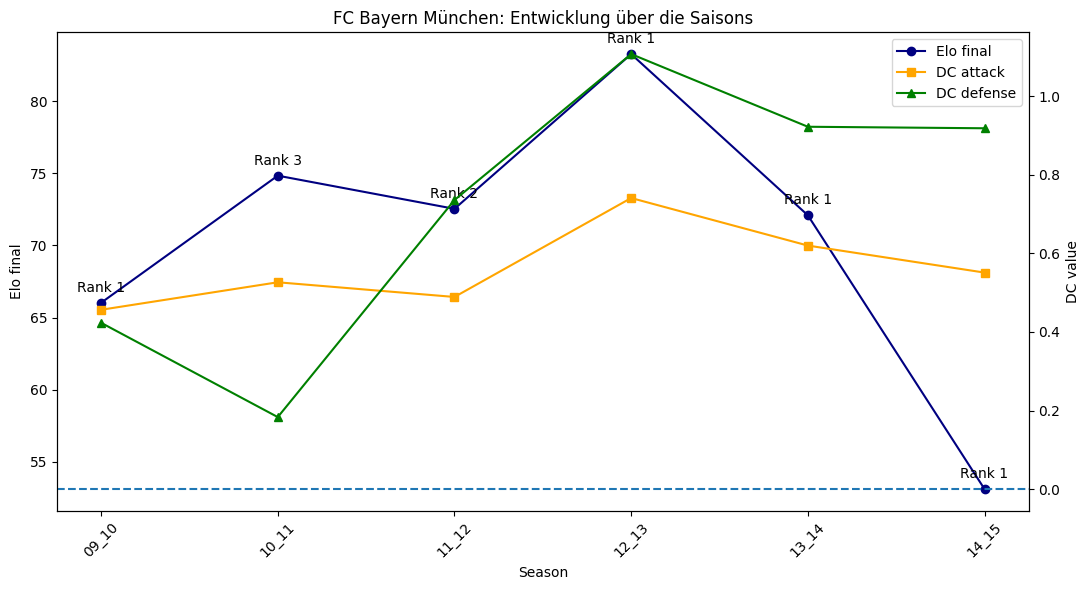

In [102]:
import matplotlib.pyplot as plt

# team auswählen
team_name = 'FC Bayern München'

# nur dieses Team filtern
df_team = team_strength_summary[team_strength_summary['Team'] == team_name].copy()

# nach Saison sortieren
df_team = df_team.sort_values('SEASON').reset_index(drop=True)

# Figure und erste Achse erzeugen
fig, ax1 = plt.subplots(figsize=(11, 6))

# zweite y-Achse für DC attack / defense erzeugen
ax2 = ax1.twinx()

# Elo auf linker Achse plotten
line1 = ax1.plot(
    df_team['SEASON'],
    df_team['Elo_final'],
    marker='o',
    label='Elo final',
    color='navy'
)

# DC attack auf rechter Achse plotten
line2 = ax2.plot(
    df_team['SEASON'],
    df_team['DC_attack'],
    marker='s',
    label='DC attack',
    color='orange'
)

# DC defense auf rechter Achse plotten
line3 = ax2.plot(
    df_team['SEASON'],
    df_team['DC_defense'],
    marker='^',
    label='DC defense',
    color='green'
)

# Rank als Text an die Elo-Punkte schreiben
for i, row in df_team.iterrows():
    ax1.annotate(
        f"Rank {int(row['Rank'])}",
        (row['SEASON'], row['Elo_final']),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

# Titel
plt.title(f'{team_name}: Entwicklung über die Saisons')

# x-Achse beschriften
ax1.set_xlabel('Season')

# linke y-Achse beschriften
ax1.set_ylabel('Elo final')

# rechte y-Achse beschriften
ax2.set_ylabel('DC value')

# x-Labels drehen
ax1.tick_params(axis='x', rotation=45)

# Null-Linie für DC-Werte einzeichnen
ax2.axhline(0, linestyle='--')

# gemeinsame Legende bauen
lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='best')

# Layout sauber machen
plt.tight_layout()

# save
plt.savefig('bayern_munich_development_all_seasons_line.png', dpi=300, bbox_inches='tight')

# Plot anzeigen
plt.show()

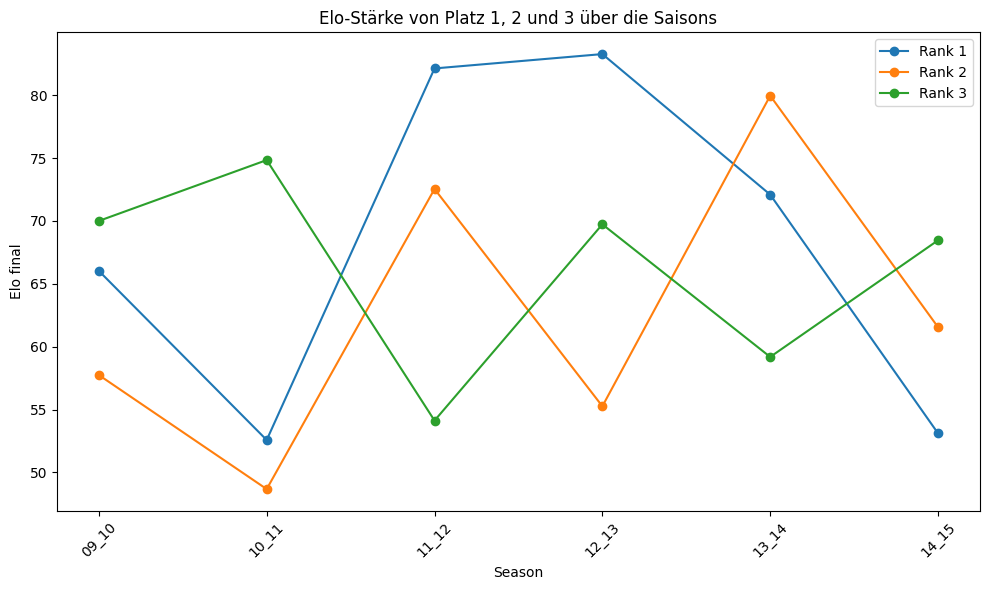

In [101]:
# wie stark waren die ersten drei Plötze über die Saisons






# nur Plätze 1, 2 und 3 auswählen
df_top3 = team_strength_summary[team_strength_summary['Rank'].isin([1, 2, 3])].copy()

# Daten für die einzelnen Ränge vorbereiten
df_rank1 = df_top3[df_top3['Rank'] == 1].sort_values('SEASON')
df_rank2 = df_top3[df_top3['Rank'] == 2].sort_values('SEASON')
df_rank3 = df_top3[df_top3['Rank'] == 3].sort_values('SEASON')

# Figure erzeugen
plt.figure(figsize=(10, 6))

# Elo-Werte der drei Platzierungen plotten
plt.plot(df_rank1['SEASON'], df_rank1['Elo_final'], marker='o', label='Rank 1')
plt.plot(df_rank2['SEASON'], df_rank2['Elo_final'], marker='o', label='Rank 2')
plt.plot(df_rank3['SEASON'], df_rank3['Elo_final'], marker='o', label='Rank 3')

# Titel und Labels
plt.title('Elo-Stärke von Platz 1, 2 und 3 über die Saisons')
plt.xlabel('Season')
plt.ylabel('Elo final')

# Legende
plt.legend()

# x-Achse lesbarer machen
plt.xticks(rotation=45)

# Layout
plt.tight_layout()

# save
plt.savefig('top_3_vs_ELO_all_seasons_line.png', dpi=300, bbox_inches='tight')

# Plot
plt.show()

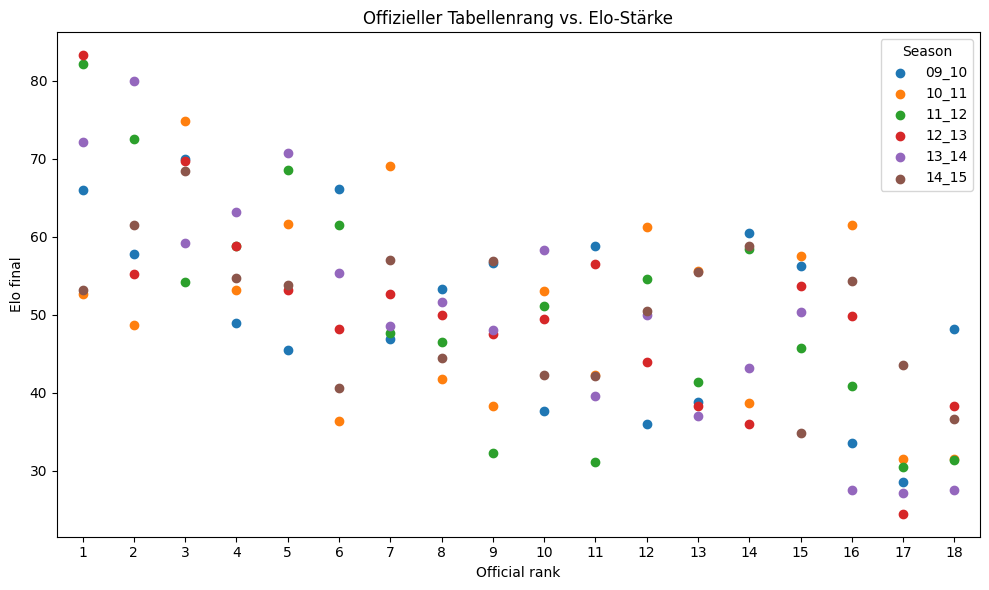

In [100]:
# how accurately does rank reflect elo strength





# gewünschte Saisons in fester Reihenfolge
season_order = ['09_10', '10_11', '11_12', '12_13', '13_14', '14_15']

# Figure erzeugen
plt.figure(figsize=(10, 6))

# für jede Saison separat plotten, damit jede Saison eine eigene Farbe bekommt
for season in season_order:
    df_season = team_strength_summary[team_strength_summary['SEASON'] == season]
    
    plt.scatter(
        df_season['Rank'],
        df_season['Elo_final'],
        label=season
    )

# Titel und Achsen
plt.title('Offizieller Tabellenrang vs. Elo-Stärke')
plt.xlabel('Official rank')
plt.ylabel('Elo final')

# x-Achse: genau ein Tick pro Rang
plt.xticks(range(1, 19))

# Rang 1 links, Rang 18 rechts
plt.xlim(0.5, 18.5)

# Legende anzeigen
plt.legend(title='Season')

# Layout
plt.tight_layout()

# save
# save
plt.savefig('rank_vs_elo_all_seasons.png', dpi=300, bbox_inches='tight')

# Plot
plt.show()

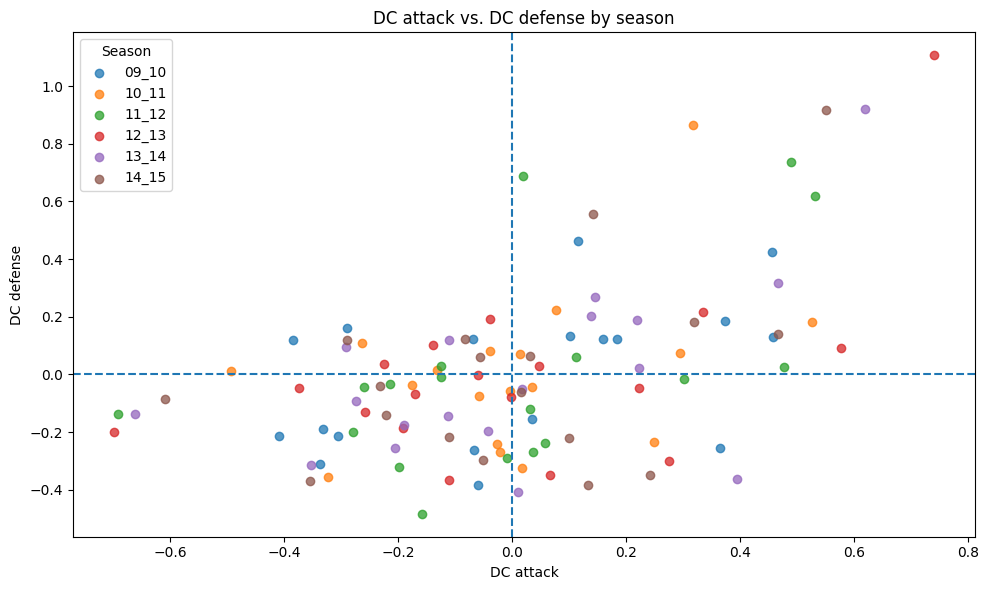

In [99]:
# DC attack vs DC defense

import matplotlib.pyplot as plt

# feste Saisonreihenfolge
season_order = ['09_10', '10_11', '11_12', '12_13', '13_14', '14_15']

# Figure erzeugen
plt.figure(figsize=(10, 6))

# jede Saison separat plotten, damit jede Saison eine eigene Farbe bekommt
for season in season_order:
    df_season = team_strength_summary[team_strength_summary['SEASON'] == season]

    plt.scatter(
        df_season['DC_attack'],
        df_season['DC_defense'],
        label=season,
        alpha=0.75
    )

# Titel und Achsen
plt.title('DC attack vs. DC defense by season')
plt.xlabel('DC attack')
plt.ylabel('DC defense')

# horizontale Linie bei 0 als Ligadurchschnitt
plt.axhline(0, linestyle='--')

# vertikale Linie bei 0 als Ligadurchschnitt
plt.axvline(0, linestyle='--')

# Legende
plt.legend(title='Season')

# Layout
plt.tight_layout()

# save
plt.savefig('dc_attack_dc_defense_all_seasons_scatter.png', dpi=300, bbox_inches='tight')
# Plot
plt.show()
plt.show()